<a href="https://colab.research.google.com/github/api-sage/diaml_projects/blob/main/Project2/pafolabi_DIAML_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data, Inference, and Applied Machine Learning**: Project Assignment II

In [63]:
#Imports all neccessary Python libraries
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

##Question 1
**Data source**: [World Bank Indicators](https://data.worldbank.org/indicator)

###a. Before looking at the data, state what kind of relationship you expect.
Before looking at the data of **GDP per capita (current
US$)** and **Prevalence of underweight, weight for age
(% of children under 5)**, I expect to see the following relationship:
1. As the world GDP increases (the GDP of countries), I expect that the percentage of underweight children decreases, yielding an inverse relationship between world GDP and percentage of underweight children.
2. The cumulative world GDP over several years.
3. The amount, either in percentage or in realised value, various countries contributed to the world GDP growth in an accounting year.
4. The percentage of underweight children in the world over a good number of years.
---
###b. Clean the data and say what you removed and why. Report how many years of observations and how many distinct countries you are left with.

In [64]:
# Data ingestion and cleaning

# 1. World GDP Data Ingestion
world_gdp_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv',
                           skiprows=4)
world_gdp_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv')
world_gdp_indicator_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/Metadata_Indicator_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv')


# 2. World Percentage of Underage Children Data Ingestion
world_pcnt_underwgth_chld_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_percent_underweight/API_SH.STA.MALN.ZS_DS2_en_csv_v2_334227.csv',
    skiprows=4)
world_pcnt_underwgth_chld_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_percent_underweight/Metadata_Country_API_SH.STA.MALN.ZS_DS2_en_csv_v2_334227.csv')
world_pcnt_underwgth_chld_metadata_indicator_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_percent_underweight/Metadata_Indicator_API_SH.STA.MALN.ZS_DS2_en_csv_v2_334227.csv')

# 3. Exploration of DFs
#world_gdp_df.head()
#world_gdp_metadata_country_df.head()
#world_gdp_indicator_df.head()

#world_pcnt_underwgth_chld_df.count()
#world_pcnt_underwgth_chld_metadata_country_df.tail()
#world_pcnt_underwgth_chld_metadata_indicator_df.head()

# 4. Data cleaning operations
region_notna = world_gdp_metadata_country_df['Region'].notna()
country_codes = world_gdp_metadata_country_df[region_notna]['Country Code']
clean_world_gdp_df = world_gdp_df[world_gdp_df['Country Code'].isin(country_codes)]
clean_world_underweight_df = world_pcnt_underwgth_chld_df[world_pcnt_underwgth_chld_df['Country Code'].isin(country_codes)]

world_gdp_long_df = clean_world_gdp_df.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(year) for year in range(1960, 2026) if str(year) in clean_world_gdp_df.columns],
    var_name='Year',
    value_name='GDP_per_capita'
)

world_pcnt_underwight_long_df = clean_world_underweight_df.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(year) for year in range(1960, 2026) if str(year) in clean_world_underweight_df.columns],
    var_name='Year',
    value_name='Percentage_Underweight'
)

merged_df = pd.merge(
    world_gdp_long_df,
    world_pcnt_underwight_long_df,
    on=['Country Code', 'Country Name','Year'],
    how='inner'
)

final_df = merged_df.dropna(subset=['GDP_per_capita', 'Percentage_Underweight'])
final_df['Year'] = final_df['Year'].astype(int)


/tmp/ipykernel_1872/787208523.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['Year'] = final_df['Year'].astype(int)


### Explanation of Data Cleaning

1.  **Filtering by Region**: Initially, both the World GDP and Underweight Children datasets contained aggregate entities (e.g., 'World', 'European Union') which are not individual countries. These were removed by filtering for 'Country Code' values that corresponded to entries with a non-null 'Region' in the `world_gdp_metadata_country_df`. This ensures that only actual country data is considered.
2.  **Melting DataFrames**: The raw data was in a wide format, with each year as a separate column. I transformed both datasets into a 'long' format using `melt()`. This reshaped the data so that each row represents a unique combination of country and year, with separate columns for 'Year', 'Country Name', 'Country Code', and the respective indicator values ('GDP_per_capita' or 'Percentage_Underweight'). This is essential for easier merging and time-series analysis.
3.  **Merging DataFrames**: The GDP per capita and Percentage Underweight data were merged into a single DataFrame (`merged_df`) using 'Country Code', 'Country Name', and 'Year' as common keys. An 'inner' merge was used, meaning only rows that have matching values in all key columns in both DataFrames were kept. This ensures we only have data points where both indicators are available for a given country and year.
4.  **Handling Missing Values**: Finally, rows where either 'GDP_per_capita' or 'Percentage_Underweight' had missing values (NaN) were dropped using `dropna()`. This step ensures that our analysis only uses complete data points, preventing skewing from incomplete observations.
5.  **Data Type Conversion**: The 'Year' column was converted to an integer type for consistency and easier numerical operations.


In [65]:
num_years = final_df['Year'].nunique()
num_countries = final_df['Country Name'].nunique()

print(f"Number of years of observations: {num_years}")
print(f"Number of distinct countries: {num_countries}")

Number of years of observations: 42
Number of distinct countries: 161


### c. Make a scatter plot of malnutrition prevalence against GDP per capita, using all available years and countries. What kind of relationship do you see, and how does it compare with your hypothesis? Then redraw the same plot with GDP per capita on a logarithmic axis, and say which of the two you would publish.

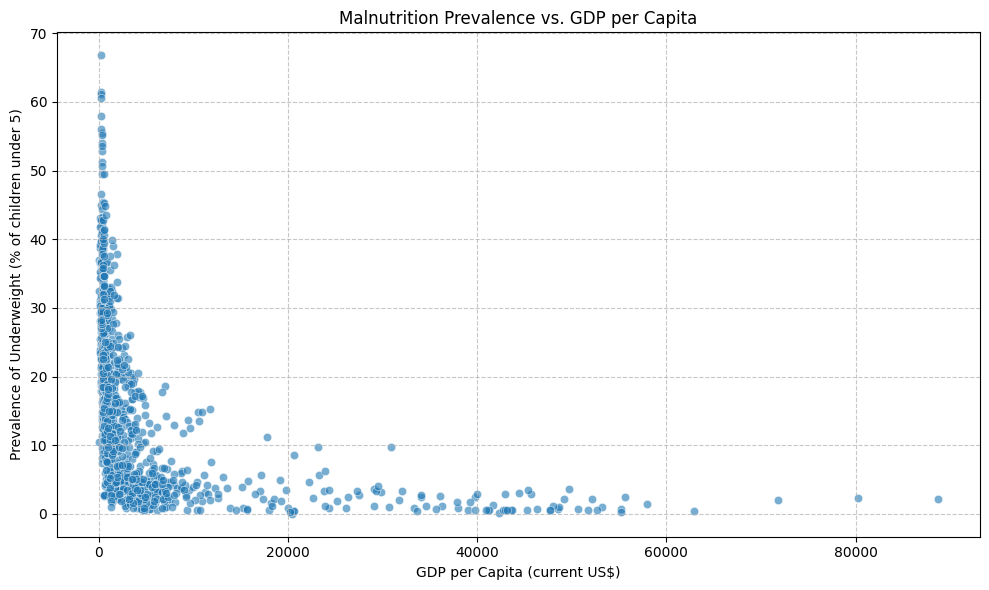

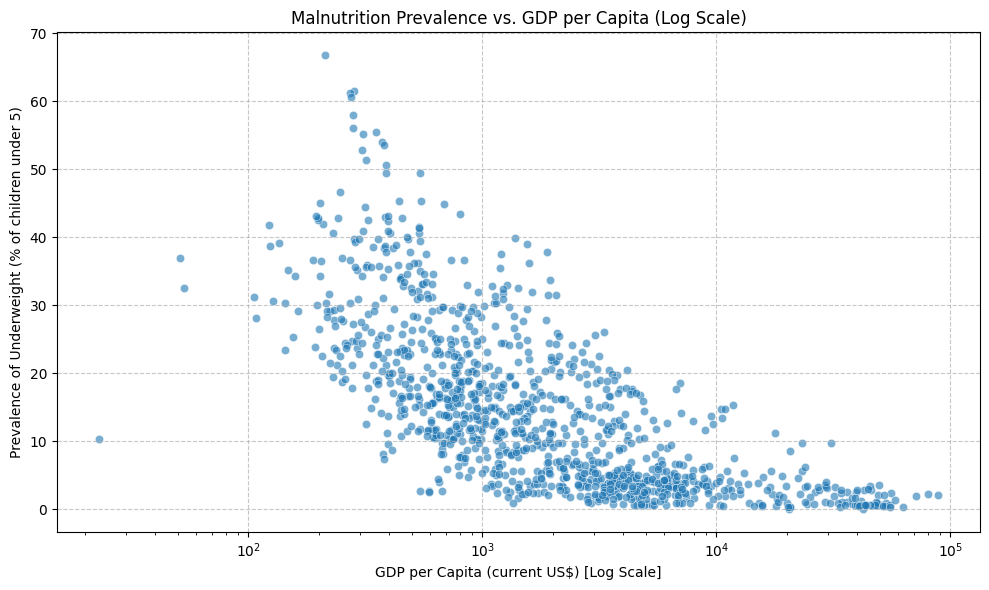

In [66]:
# Scatter plot of malnutrition prevalence against GDP per capita
fig1 = plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_df, x='GDP_per_capita', y='Percentage_Underweight', alpha=0.6)
plt.title('Malnutrition Prevalence vs. GDP per Capita')
plt.xlabel('GDP per Capita (current US$)')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Scatter plot with GDP per capita on a logarithmic axis
fig2 = plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_df, x='GDP_per_capita', y='Percentage_Underweight', alpha=0.6)
plt.xscale('log')
plt.title('Malnutrition Prevalence vs. GDP per Capita (Log Scale)')
plt.xlabel('GDP per Capita (current US$) [Log Scale]')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Analysis of Plots (Question 1.c)

**Relationship Observed (Linear Scale)**:

In the first scatter plot (linear scale), we can observe a general trend where as GDP per capita increases, the prevalence of underweight children tends to decrease. This aligns with the initial hypothesis of an inverse relationship. However, the data points are heavily clustered towards the lower end of the GDP per capita scale, making it difficult to discern patterns among countries with lower GDP and to fully appreciate the relationship across the entire range.

**Relationship Observed (Logarithmic Scale)**:

The second scatter plot, with GDP per capita on a logarithmic axis, provides a much clearer view of the relationship. The logarithmic scale compresses the higher GDP values and expands the lower GDP values, spreading out the clustered points and revealing more detail. In this plot, the inverse relationship is more evident and appears more consistent across different income levels. The distribution of data points is more uniform, allowing for better identification of trends and outliers.

**Which plot to publish?**:

I would publish the **scatter plot with GDP per capita on a logarithmic axis**. This is because:

*   **Better Visualization of Skewed Data**: Economic data like GDP per capita often has a heavily skewed distribution, with a few high-income countries and many low-to-middle-income countries. A logarithmic scale effectively handles this skewness, making the distribution of data points more interpretable.
*   **Clearer Trend Identification**: The inverse relationship between GDP per capita and malnutrition prevalence is much more clearly and evenly depicted across the range of GDP values on a logarithmic scale. It allows us to observe nuances in the relationship that are obscured on a linear scale.
*   **Enhanced Detail for Lower GDP Countries**: The logarithmic scale provides more visual emphasis on the differences among lower GDP countries, which are often the most relevant for studying malnutrition.


### d. Make a scatter plot coloured by geographical region and another coloured by income level. Which of the two plots is more informative?

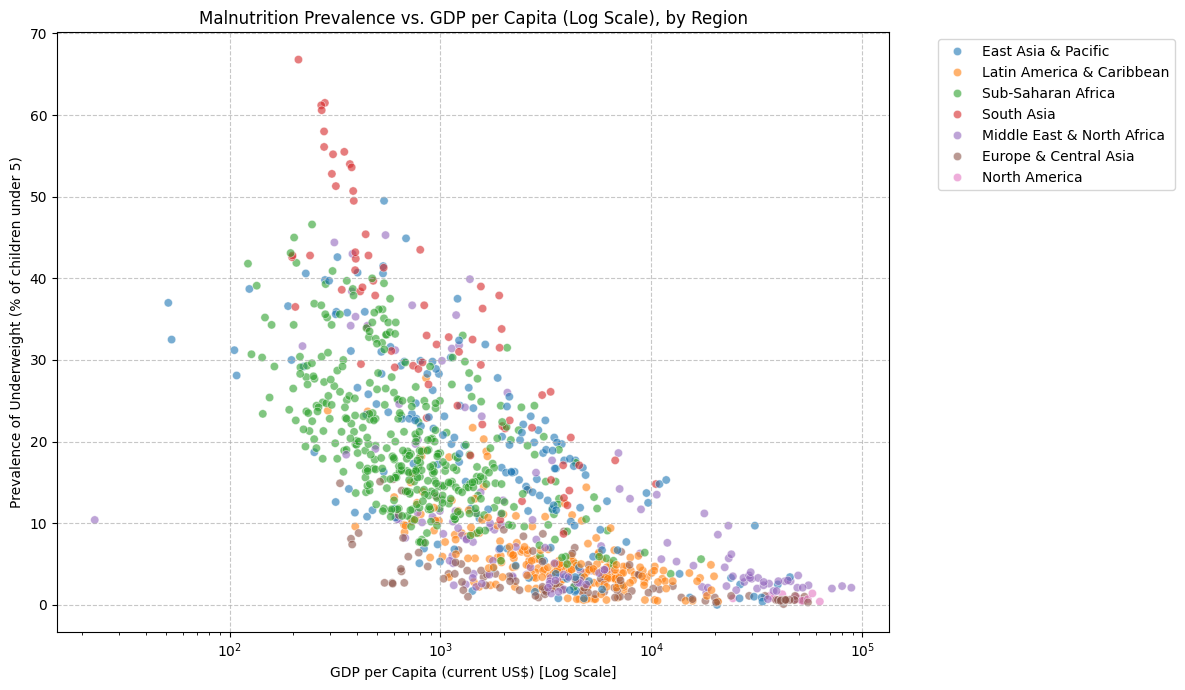

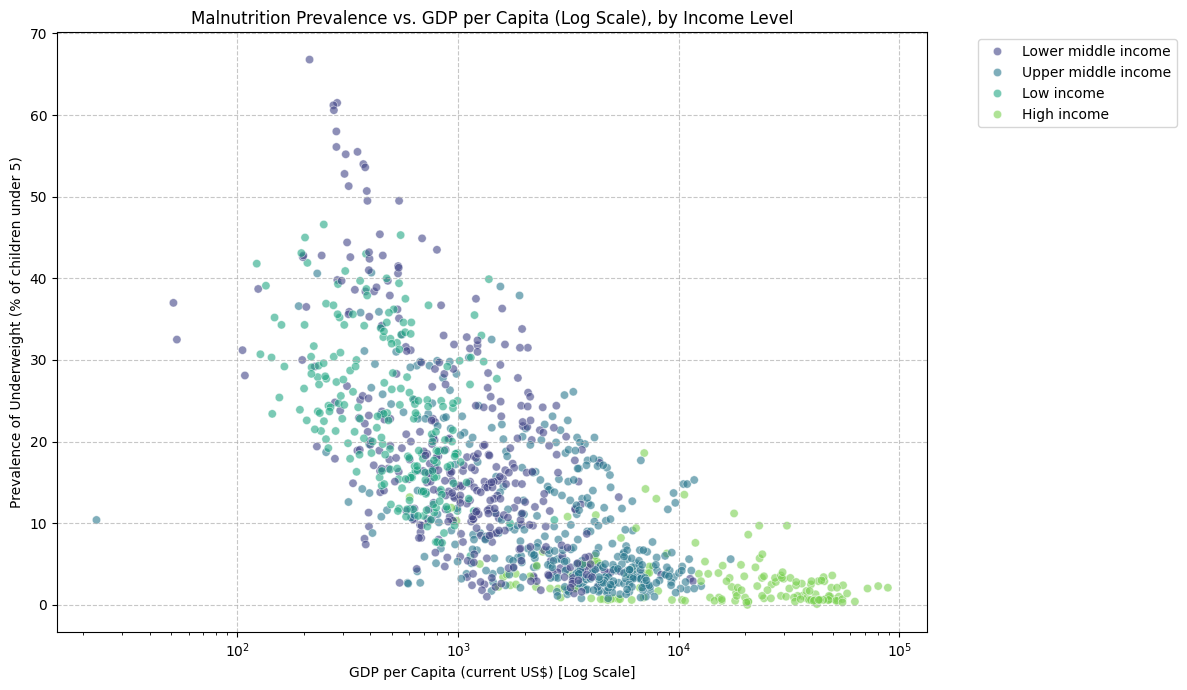

In [67]:
metadata_df = world_gdp_metadata_country_df[['Country Code', 'Region', 'IncomeGroup']].copy()
final_df_with_metadata = pd.merge(final_df, metadata_df, on='Country Code', how='left')

# Scatter plot colored by Geographical Region
fig3 = plt.figure(figsize=(12, 7))
sns.scatterplot(data=final_df_with_metadata, x='GDP_per_capita', y='Percentage_Underweight', hue='Region', alpha=0.6, palette='tab10')
plt.xscale('log')
plt.title('Malnutrition Prevalence vs. GDP per Capita (Log Scale), by Region')
plt.xlabel('GDP per Capita (current US$) [Log Scale]')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scatter plot colored by Income Level
fig4 = plt.figure(figsize=(12, 7))
sns.scatterplot(data=final_df_with_metadata, x='GDP_per_capita', y='Percentage_Underweight', hue='IncomeGroup', alpha=0.6, palette='viridis')
plt.xscale('log')
plt.title('Malnutrition Prevalence vs. GDP per Capita (Log Scale), by Income Level')
plt.xlabel('GDP per Capita (current US$) [Log Scale]')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Analysis of Plots (Question 1.d)

**Which plot is more informative?**

Both plots offer valuable insights, but the **scatter plot colored by Income Level is generally more informative** for understanding the relationship between GDP per capita and malnutrition prevalence.

Here's why:

*   **Direct Correlation with GDP**: Income Group is directly defined by GDP per capita. Therefore, coloring by income level inherently reinforces and clarifies the underlying trend. We can clearly see how countries transition from 'Low income' (typically higher malnutrition, lower GDP) through 'Lower middle income', 'Upper middle income', to 'High income' (typically lower malnutrition, higher GDP), creating a more structured and coherent visual progression.

*   **Clearer Segregation of Trends**: The income level categories tend to group countries with similar economic development and, consequently, similar levels of malnutrition and GDP. This provides a more distinct and understandable segmentation of the data, allowing us to easily identify clusters and patterns within each income group.

*   **Actionable Insights**: From a policy perspective, understanding the relationship within specific income groups can be more actionable. Interventions for malnutrition might differ significantly between a 'Low income' country and a 'High income' country, even if both are in the same geographical region.

**Comparison with Geographical Region Plot**:

The plot colored by geographical region is also useful, as it shows regional disparities. For example, countries in 'Sub-Saharan Africa' might consistently appear at the lower end of the GDP scale with higher malnutrition. However, geographical regions are more diverse in terms of economic development. A single region might contain countries with vastly different GDPs and malnutrition rates, leading to more overlapping and less clear-cut distinctions between the colored groups compared to income levels. While it highlights regional clusters, it doesn't explain the *why* of the GDP-malnutrition relationship as effectively as income groups do.

In conclusion, while both plots offer different perspectives, the **Income Level plot provides a more direct and interpretable visual explanation of the relationship between a country's economic standing (proxied by GDP) and its child malnutrition rates.**

### e. Plot the number of observations per year. What do you observe about reporting frequency?

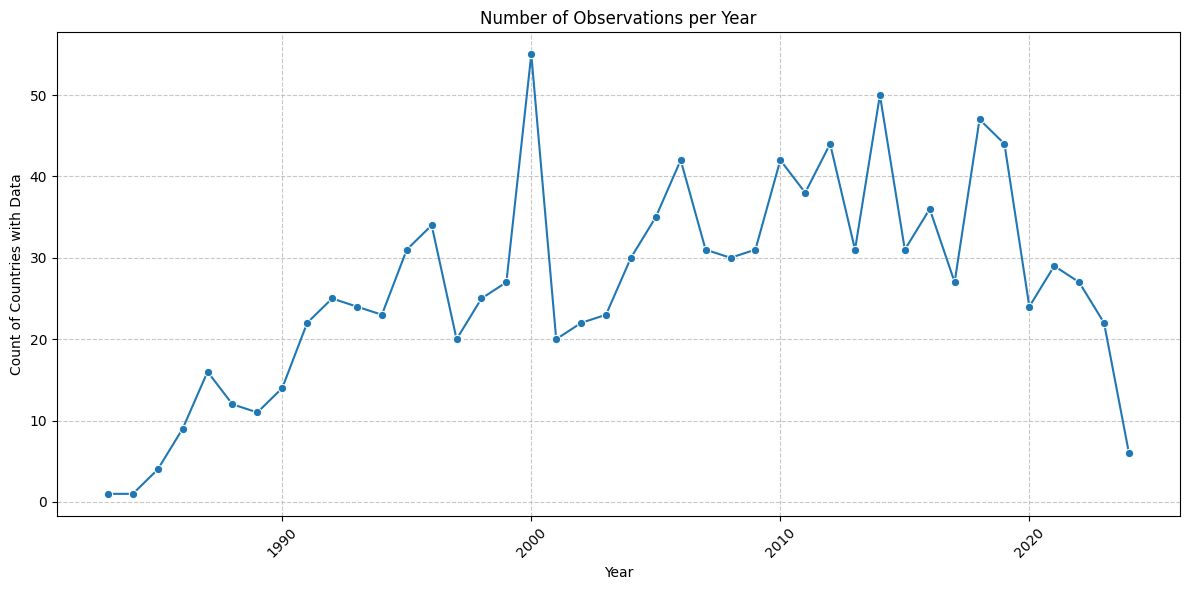

In [68]:
# Plot the number of observations per year
observations_per_year = final_df.groupby('Year').size().reset_index(name='Number of Observations')

fig5 = plt.figure(figsize=(12, 6))
sns.lineplot(data=observations_per_year, x='Year', y='Number of Observations', marker='o')
plt.title('Number of Observations per Year')
plt.xlabel('Year')
plt.ylabel('Count of Countries with Data')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analysis of Reporting Frequency (Question 1.e)

**Observations about reporting frequency:**

The plot showing the 'Number of Observations per Year' reveals several insights into the reporting frequency of both GDP per capita and the prevalence of underweight children:

*   **Sparse Data in Earlier Years**: There are very few observations in the earlier years (e.g., prior to 1980s). This suggests that data collection for one or both indicators was either not comprehensive or not systematically recorded for many countries during those periods.

*   **Increasing Trend over Time**: From the late 1980s or early 1990s, there is a clear upward trend in the number of observations per year. This indicates an improvement in data collection and reporting over time, with more countries providing data for both indicators.

*   **Fluctuations and Gaps**: Despite the general increasing trend, there are noticeable fluctuations and gaps in reporting. Some years have fewer observations than preceding or succeeding years, suggesting that data might not be collected annually for all countries or that reporting can be irregular.

*   **Peak Reporting**: The number of observations appears to peak around the mid-2000s to early 2010s, after which there might be a slight decline or stabilization. This could indicate periods of focused data collection efforts or changes in reporting methodologies.

*   **Most Recent Years Lack Data**: There's a sharp drop-off in observations for the most recent years (e.g., after 2015-2020). This is expected as data collection and compilation often take time, and the latest figures might not yet be available in the datasets. The datasets might also contain 'future' years with no actual data yet, contributing to the drop-off.

In summary, the reporting frequency for these indicators has improved significantly over the decades, though it remains somewhat inconsistent annually, and there is a natural lag in the availability of the most recent data.

## Question 2

For Question 2, we need to download daily closing prices for Wheat (ZW=F), Crude Oil (CL=F), and Gold (GC=F) from Yahoo Finance. This requires the `yfinance` library.

### a. Load the three series and synchronize their timestamps onto a common date index using forward fill.

In [69]:
# Define the tickers and date range
tickers = ['ZW=F', 'CL=F', 'GC=F']
start_date = '2000-08-01'
end_date = '2026-08-31'

# Download data for each ticker
data = {} # Initialize an empty dictionary
for ticker in tickers:
    try:
        ticker_data = yf.download(ticker, start=start_date, end=end_date)
        # Extract the 'Close' price series
        close_series = ticker_data['Close']
        # Explicitly set the name of the series to the ticker symbol
        close_series.name = ticker
        data[ticker] = close_series
    except Exception as e:
        print(f"Could not download data for {ticker}: {e}")

# Create a common date index
# Start with the index of the first series, then add other dates
all_dates = pd.DatetimeIndex([])
for ticker in data:
    all_dates = all_dates.union(data[ticker].index)

# Create a combined DataFrame and synchronize timestamps with forward fill
combined_df_ffill = pd.DataFrame(index=all_dates)
for ticker in data:
    # Now, data[ticker] is already a Series with its name set correctly
    combined_df_ffill = combined_df_ffill.join(data[ticker], how='outer')

# Apply forward fill
combined_df_ffill = combined_df_ffill.ffill()

print("Units for each commodity:")
print("Wheat (ZW=F): USD per bushel")
print("Crude Oil (CL=F): USD per barrel")
print("Gold (GC=F): USD per troy ounce")

print("\nSynchronized DataFrame (first 5 rows with forward fill):")
display(combined_df_ffill.head())

print("\nSynchronized DataFrame (last 5 rows with forward fill):")
display(combined_df_ffill.tail())

/tmp/ipykernel_1872/17995327.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1872/17995327.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1872/17995327.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Units for each commodity:
Wheat (ZW=F): USD per bushel
Crude Oil (CL=F): USD per barrel
Gold (GC=F): USD per troy ounce

Synchronized DataFrame (first 5 rows with forward fill):


,ZW=F,CL=F,GC=F
2000-08-01,245.00,NaN,NaN
2000-08-02,246.50,NaN,NaN
2000-08-03,242.25,NaN,NaN
2000-08-04,236.50,NaN,NaN
2000-08-07,233.50,NaN,NaN



Synchronized DataFrame (last 5 rows with forward fill):


,ZW=F,CL=F,GC=F
2026-08-24,681.75,85.010002,4640.799805
2026-08-25,685.50,82.360001,4638.100098
2026-08-26,730.50,82.230003,4598.200195
2026-08-27,742.75,83.529999,4609.700195
2026-08-28,767.00,83.400002,4478.100098


### b. Make commodities comparable and plot them on the same graph

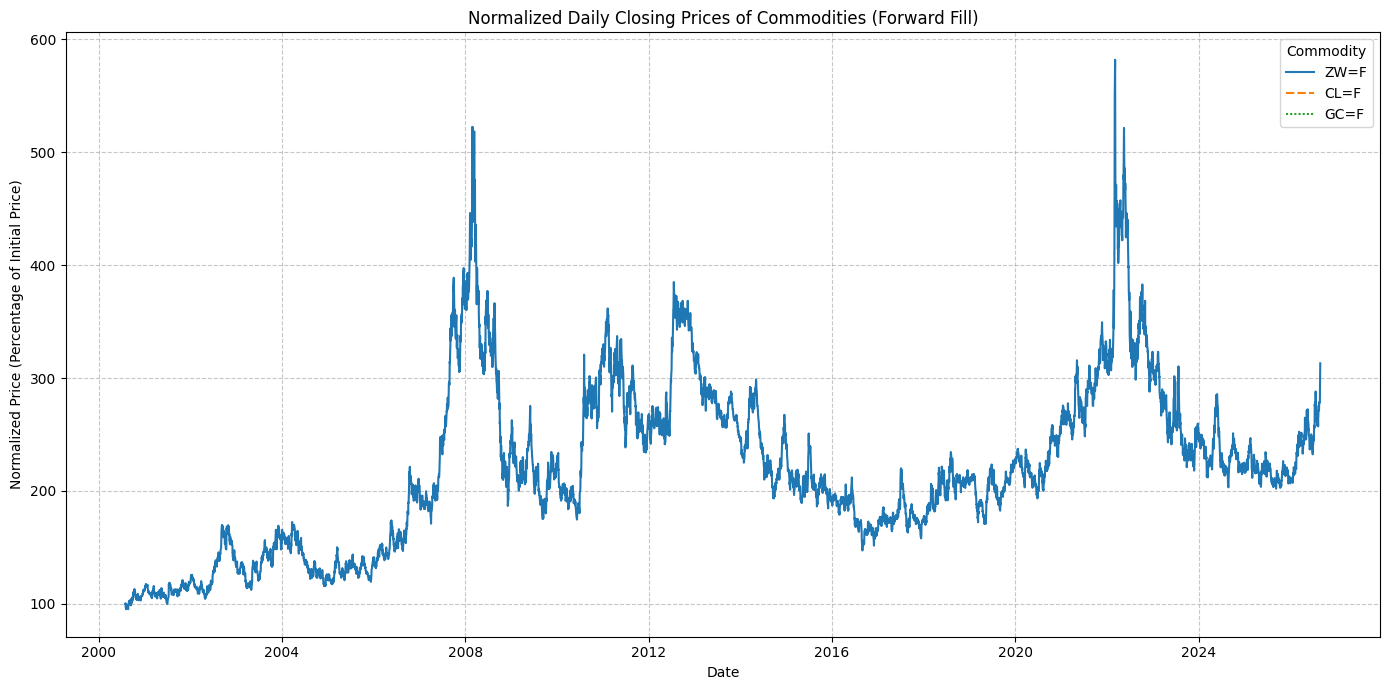


Explanation of choice:
I chose to normalize the prices by dividing each series by its initial value and multiplying by 100. This makes the commodities comparable by showing their price movement as a percentage change from a common starting point (100%).

What this choice does preserve:
- It preserves the relative fluctuations and trends of each commodity over time.
- It allows for a direct visual comparison of performance, showing which commodity has grown or declined the most proportionally.

What this choice does NOT preserve:
- It does NOT preserve the absolute price levels or the actual magnitude of price differences in USD.
- It does NOT preserve the volatility in absolute terms (e.g., a $1 change in Gold is very different from a $1 change in Wheat, but on a percentage basis, they might look similar).


In [70]:
# Make the series comparable by normalizing to their initial values
# This shows their percentage change relative to the start date.
normalized_df = combined_df_ffill / combined_df_ffill.iloc[0] * 100

# Plot all three price series on the same graph
plt.figure(figsize=(14, 7))
sns.lineplot(data=normalized_df, linewidth=1.5)
plt.title('Normalized Daily Closing Prices of Commodities (Forward Fill)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Percentage of Initial Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Commodity')
plt.tight_layout()
plt.show()

print("\nExplanation of choice:")
print("I chose to normalize the prices by dividing each series by its initial value and multiplying by 100. This makes the commodities comparable by showing their price movement as a percentage change from a common starting point (100%).")
print("\nWhat this choice does preserve:")
print("- It preserves the relative fluctuations and trends of each commodity over time.")
print("- It allows for a direct visual comparison of performance, showing which commodity has grown or declined the most proportionally.")
print("\nWhat this choice does NOT preserve:")
print("- It does NOT preserve the absolute price levels or the actual magnitude of price differences in USD.")
print("- It does NOT preserve the volatility in absolute terms (e.g., a $1 change in Gold is very different from a $1 change in Wheat, but on a percentage basis, they might look similar).")

### c. Mark the maximum and minimum of each series with coloured dots and include a legend.

/tmp/ipykernel_1872/3241596734.py:16: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max_idx = normalized_df[col].idxmax()
/tmp/ipykernel_1872/3241596734.py:17: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  min_idx = normalized_df[col].idxmin()
/tmp/ipykernel_1872/3241596734.py:16: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max_idx = normalized_df[col].idxmax()
/tmp/ipykernel_1872/3241596734.py:17: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  min_idx = normalized_df[col].idxmin()


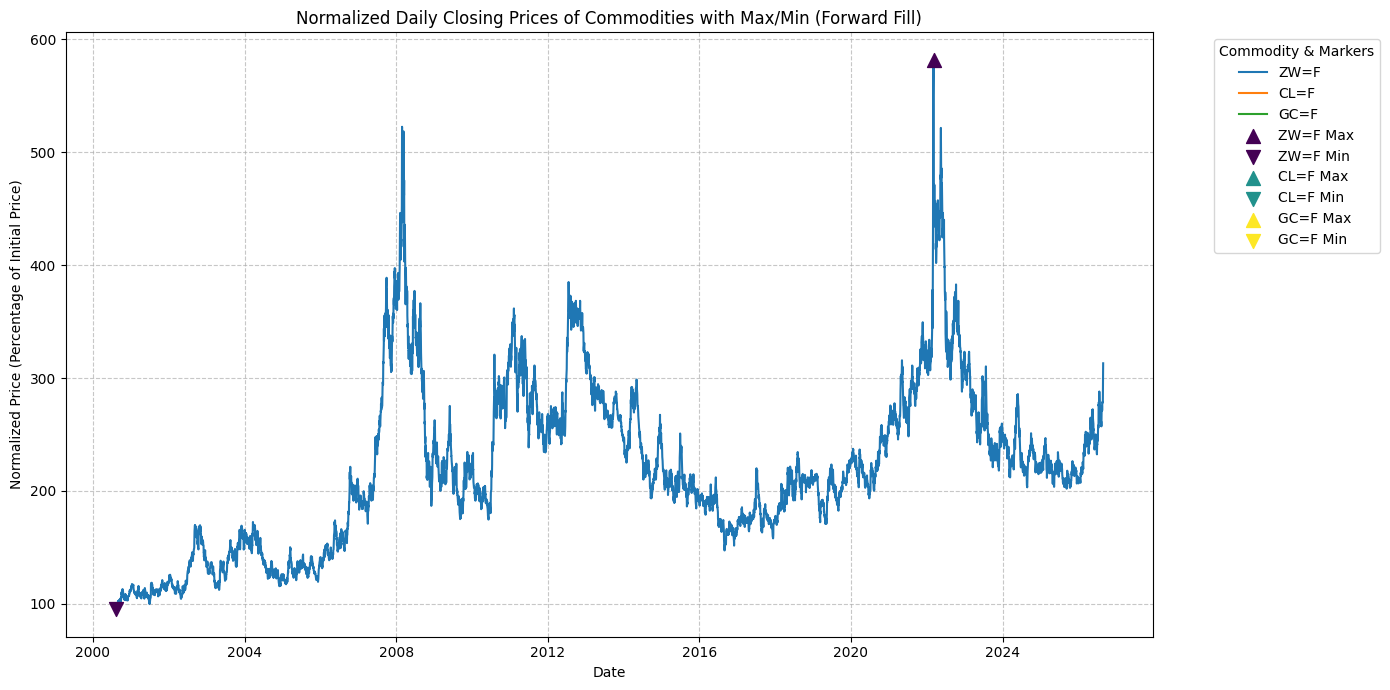

In [71]:
plt.figure(figsize=(14, 7))

# Plot lines with proper labels for legend
sns.lineplot(data=normalized_df.reset_index().melt(id_vars='index', var_name='Commodity', value_name='Normalized Price'),
             x='index', y='Normalized Price', hue='Commodity', linewidth=1.5, ax=plt.gca())

# Mark max and min for each series
colors = plt.cm.viridis(np.linspace(0, 1, len(normalized_df.columns))) # Re-initialize colors if needed

# Collect handles and labels for a combined legend
handles, labels = plt.gca().get_legend_handles_labels()

for i, col in enumerate(normalized_df.columns):
    max_val = normalized_df[col].max()
    min_val = normalized_df[col].min()
    max_idx = normalized_df[col].idxmax()
    min_idx = normalized_df[col].idxmin()

    # Plot max point
    max_scatter = plt.scatter(max_idx, max_val, color=colors[i], marker='^', s=100, label=f'{col} Max', zorder=5)
    # Plot min point
    min_scatter = plt.scatter(min_idx, min_val, color=colors[i], marker='v', s=100, label=f'{col} Min', zorder=5)

    # Add scatter handles and labels to the collected lists
    handles.append(max_scatter)
    labels.append(f'{col} Max')
    handles.append(min_scatter)
    labels.append(f'{col} Min')

plt.title('Normalized Daily Closing Prices of Commodities with Max/Min (Forward Fill)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Percentage of Initial Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(handles=handles, labels=labels, title='Commodity & Markers', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### d. The three prices are quoted in different units: Does this affect the shape of any series, the comparison between them, or both? Explain.

In [72]:
print("**Does the difference in units affect the shape of any series, the comparison between them, or both?**\n")
print("The difference in units (USD per bushel for wheat, USD per barrel for crude oil, USD per troy ounce for gold) **does not affect the *shape* of any individual series**, but it profoundly affects the **comparison between them** in absolute terms. However, by normalizing the series (as done in part b), we can compare their *relative* performance regardless of their original units.\n")

print("**Explanation:**\n")

print("1.  **Shape of Individual Series:** The shape of an individual series (e.g., the plot of Gold prices over time) is determined by its own price movements, irrespective of the units it is quoted in. Whether gold is measured in USD per ounce or some other currency/unit, its percentage changes and overall trend will remain the same. The raw numerical values would change, but the graphical representation of its proportional movement (its 'shape') would not.\n")

print("2.  **Comparison Between Series (Absolute Terms):** The different units make direct absolute comparisons between the commodities meaningless. For example, comparing a raw price of $700 for wheat to $80 for crude oil is misleading because they represent different quantities and measures. Gold prices being in thousands per troy ounce, while wheat is in hundreds per bushel, means their absolute magnitudes are entirely incomparable without a common baseline. If we were to plot the raw prices on the same graph without normalization, the commodity with the highest absolute price (Gold, in this case) would visually dominate the plot, making it difficult to discern movements in the other, lower-priced commodities.\n")

print("3.  **Comparison Between Series (Relative Terms - after normalization):** Our normalization (converting prices to percentage of initial value) makes the comparison between commodities valid by focusing on *relative* change. This allows us to see which commodity has experienced the largest *proportional* increase or decrease from its starting point. In this normalized view, the original units become irrelevant because we are looking at unit-less percentage changes. The *shape* of the normalized series then reflects its relative performance, allowing for a fair comparison of trends and volatility in a percentage context across all three commodities.\n")

print("**Conclusion:** The original units themselves do not alter the intrinsic shape of an individual series' fluctuations. However, they make direct, absolute comparisons between different series difficult. Normalization is a technique used to overcome this unit-dependency and enable meaningful relative comparisons of performance across diverse assets.")

**Does the difference in units affect the shape of any series, the comparison between them, or both?**

The difference in units (USD per bushel for wheat, USD per barrel for crude oil, USD per troy ounce for gold) **does not affect the *shape* of any individual series**, but it profoundly affects the **comparison between them** in absolute terms. However, by normalizing the series (as done in part b), we can compare their *relative* performance regardless of their original units.

**Explanation:**

1.  **Shape of Individual Series:** The shape of an individual series (e.g., the plot of Gold prices over time) is determined by its own price movements, irrespective of the units it is quoted in. Whether gold is measured in USD per ounce or some other currency/unit, its percentage changes and overall trend will remain the same. The raw numerical values would change, but the graphical representation of its proportional movement (its 'shape') would not.

2.  **Comparison Between Series (Absol

### e. Rerun Part A, B, and C using an inner join instead of forward-fill. Does it change your answers?

In [73]:
# Define the tickers and date range
tickers = ['ZW=F', 'CL=F', 'GC=F']
start_date = '2000-08-01'
end_date = '2026-08-31'

# Download data for each ticker
data_inner = {}
for ticker in tickers:
    try:
        ticker_data = yf.download(ticker, start=start_date, end=end_date)
        close_series = ticker_data['Close']
        close_series.name = ticker
        data_inner[ticker] = close_series
    except Exception as e:
        print(f"Could not download data for {ticker}: {e}")

# Combine into a single DataFrame using inner join
# Start with the first series, then merge others
combined_df_inner = pd.DataFrame()
if data_inner:
    first_ticker = list(data_inner.keys())[0]
    combined_df_inner = pd.DataFrame(data_inner[first_ticker])

    for ticker in list(data_inner.keys())[1:]:
        combined_df_inner = combined_df_inner.merge(data_inner[ticker], left_index=True, right_index=True, how='inner')

print("\nSynchronized DataFrame (first 5 rows with inner join):\n")
display(combined_df_inner.head())
print("\nSynchronized DataFrame (last 5 rows with inner join):\n")
display(combined_df_inner.tail())

# 2.b. Make commodities comparable and plot them on the same graph (Inner Join)
normalized_df_inner = combined_df_inner / combined_df_inner.iloc[0] * 100

plt.figure(figsize=(14, 7))
sns.lineplot(data=normalized_df_inner.reset_index().melt(id_vars='index', var_name='Commodity', value_name='Normalized Price'),
             x='index', y='Normalized Price', hue='Commodity', linewidth=1.5, ax=plt.gca())
plt.title('Normalized Daily Closing Prices of Commodities (Inner Join)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Percentage of Initial Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Commodity')
plt.tight_layout()
plt.show()

# 2.c. Mark the maximum and minimum of each series with coloured dots and include a legend (Inner Join)
plt.figure(figsize=(14, 7))
sns.lineplot(data=normalized_df_inner.reset_index().melt(id_vars='index', var_name='Commodity', value_name='Normalized Price'),
             x='index', y='Normalized Price', hue='Commodity', linewidth=1.5, ax=plt.gca())

# Collect handles and labels for a combined legend
handles, labels = plt.gca().get_legend_handles_labels()

colors = plt.cm.viridis(np.linspace(0, 1, len(normalized_df_inner.columns)))
for i, col in enumerate(normalized_df_inner.columns):
    max_val = normalized_df_inner[col].max()
    min_val = normalized_df_inner[col].min()
    max_idx = normalized_df_inner[col].idxmax()
    min_idx = normalized_df_inner[col].idxmin()

    max_scatter = plt.scatter(max_idx, max_val, color=colors[i], marker='^', s=100, label=f'{col} Max', zorder=5)
    min_scatter = plt.scatter(min_idx, min_val, color=colors[i], marker='v', s=100, label=f'{col} Min', zorder=5)

    # Add scatter handles and labels to the collected lists
    handles.append(max_scatter)
    labels.append(f'{col} Max')
    handles.append(min_scatter)
    labels.append(f'{col} Min')

plt.title('Normalized Daily Closing Prices of Commodities with Max/Min (Inner Join)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Percentage of Initial Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(handles=handles, labels=labels, title='Commodity & Markers', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n**Does using an inner join instead of forward-fill change your answers?**\n")
print("Yes, using an inner join instead of forward-fill significantly changes the results and, consequently, the answers to parts A, B, and C.\n")

print("**Impact on Part A (Synchronization):**\n")
print("-   **Forward-fill (ffill):** Preserves all dates present in any of the individual series. If a date is missing for one commodity, its price is carried forward from the last available trading day. This results in a larger DataFrame with potentially more continuous data, assuming prices remain constant on non-trading days.\n")
print("-   **Inner Join:** Only includes dates for which *all three* commodities have a trading price. This means any date where even one commodity did not trade will be excluded from the combined DataFrame. The resulting DataFrame will be smaller and only contain dates that are common to all series. This is evident by comparing the number of rows/dates in `combined_df_ffill` versus `combined_df_inner`. The inner join ensures that every data point reflects an actual observed price for all assets on that specific day.\n")

print("**Impact on Part B (Comparability and Plot:**\n")
print("-   The overall trend and relative movements in the normalized plots will be broadly similar, as both methods aim to show relative price changes. However, the exact curves will differ because the set of dates included is different. The inner join plot might appear slightly more 'sparse' or 'jagged' if there are many non-common trading days, whereas the ffill plot fills in those gaps, potentially smoothing the curves by repeating values.\n")
print("-   The absolute normalized values (percentage changes) on specific dates will be calculated based on a different set of initial prices and a different set of dates. This means the percentage changes observed for certain periods might slightly differ, as the start date (iloc[0]) for the normalization could correspond to a different actual date depending on which dates are common.\n")

print("**Impact on Part C (Max/Min Markers):**\n")
print("-   The exact dates and values for the maximum and minimum points for each series will likely change. Since the inner join removes non-common dates, it's possible that the absolute maximum or minimum price for a commodity occurred on a day when another commodity did not trade, and thus that date would be excluded from the inner-joined dataset. This could lead to a different (sub-optimal) max/min being identified within the reduced dataset.\n")
print("-   Visually, the plot will still show max/min markers, but they will be based on the common trading days only.\n")

print("**Overall Conclusion:** The choice between forward-fill and inner join depends on the analytical goal. Forward-fill is useful when you want to maintain a continuous time series and assume the last observed price holds for non-trading days. Inner join provides a cleaner dataset of only synchronously traded days, which is crucial for analyses where simultaneous observation is key (e.g., correlation between assets on actual trading days). For this problem, using an inner join results in fewer data points and potentially alters the identified extrema, demonstrating the importance of data synchronization strategy.")

/tmp/ipykernel_1872/3658409737.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1872/3658409737.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1872/3658409737.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Synchronized DataFrame (first 5 rows with inner join):



Ticker,ZW=F,CL=F,GC=F
Date,,,
2000-08-30,246.25,33.400002,273.899994
2000-08-31,251.00,33.099998,278.299988
2000-09-01,251.00,33.380001,277.000000
2000-09-05,250.25,33.799999,275.799988
2000-09-06,253.00,34.950001,274.200012



Synchronized DataFrame (last 5 rows with inner join):



Ticker,ZW=F,CL=F,GC=F
Date,,,
2026-08-24,681.75,85.010002,4640.799805
2026-08-25,685.50,82.360001,4638.100098
2026-08-26,730.50,82.230003,4598.200195
2026-08-27,742.75,83.529999,4609.700195
2026-08-28,767.00,83.400002,4478.100098


KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['index']"

<Figure size 1400x700 with 0 Axes>

## Question 3

### a. Extract data for 2022 and clean it. How many valid countries remain for each indicator, and what did you do to avoid statistical bias and double-counting?

In [ ]:
# 1. Data Ingestion for Children Out of School
children_out_of_school_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/children_out_of_school/API_SE.PRM.UNER.ZS_DS2_en_csv_v2_41962.csv',
    skiprows=4)
children_out_of_school_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/children_out_of_school/Metadata_Country_API_SE.PRM.UNER.ZS_DS2_en_csv_v2_41962.csv')

# 2. Data Ingestion for Adolescents Out of School
adolescents_out_of_school_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/adolescents_out_of_school/API_SE.SEC.UNER.LO.ZS_DS2_en_csv_v2_39770.csv',
    skiprows=4)
adolescents_out_of_school_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/adolescents_out_of_school/Metadata_Country_API_SE.SEC.UNER.LO.ZS_DS2_en_csv_v2_39770.csv')

# 3. Clean Data for 2022
def clean_and_extract_2022_data(data_df, metadata_country_df, indicator_col_name):
    # Filter out non-country aggregates based on 'Region' in metadata
    region_notna = metadata_country_df['Region'].notna()
    country_codes = metadata_country_df[region_notna]['Country Code']
    clean_data_df = data_df[data_df['Country Code'].isin(country_codes)].copy()

    # Extract data for 2022
    # Check if '2022' column exists before trying to access it
    if '2022' in clean_data_df.columns:
        df_2022 = clean_data_df[['Country Name', 'Country Code', '2022']].copy()
        df_2022.rename(columns={'2022': indicator_col_name}, inplace=True)
    else:
        print(f"Warning: '2022' column not found in data. Creating empty DataFrame.")
        df_2022 = pd.DataFrame(columns=['Country Name', 'Country Code', indicator_col_name])

    # Drop rows with NaN values for the indicator in 2022
    df_2022.dropna(subset=[indicator_col_name], inplace=True)

    return df_2022

# Clean and extract for children out of school
children_out_of_school_2022 = clean_and_extract_2022_data(
    children_out_of_school_df, children_out_of_school_metadata_country_df, 'Children_Out_of_School_Percent')

# Clean and extract for adolescents out of school
adolescents_out_of_school_2022 = clean_and_extract_2022_data(
    adolescents_out_of_school_df, adolescents_out_of_school_metadata_country_df, 'Adolescents_Out_of_School_Percent')

print("Children out of school (2022) - first 5 rows:")
display(children_out_of_school_2022.head())
print("\nAdolescents out of school (2022) - first 5 rows:")
display(adolescents_out_of_school_2022.head())


In [ ]:
# Report valid countries
num_valid_children_countries = children_out_of_school_2022['Country Code'].nunique()
num_valid_adolescents_countries = adolescents_out_of_school_2022['Country Code'].nunique()

print(f"Number of valid countries for 'Children out of school' in 2022: {num_valid_children_countries}")
print(f"Number of valid countries for 'Adolescents out of school' in 2022: {num_valid_adolescents_countries}")

### Explanation of Data Cleaning and Bias Avoidance (Question 3.a)

**Data Cleaning Steps:**

1.  **Filtering by Region**: For both datasets, I filtered out non-country aggregates (like 'World', 'European Union', 'Sub-Saharan Africa', etc.) by cross-referencing `Country Code` with the `Metadata_Country` files. This ensures that only actual country-level data is used for analysis, avoiding statistical bias from including regional or income-group aggregates that are not independent entities.

2.  **Extracting 2022 Data**: I specifically selected the data for the year 2022 from each cleaned DataFrame. This isolates the relevant year for the analysis as requested.

3.  **Handling Missing Values (`dropna`)**: After extracting the 2022 data, I removed any rows where the indicator's value for 2022 was missing (NaN). This ensures that only countries with reported data for the specified year are included in the counts and subsequent statistical calculations.

**Avoiding Statistical Bias and Double-Counting:**

*   **Exclusion of Aggregates**: By filtering out non-country aggregates based on the `Region` column in the metadata, I ensured that we are only analyzing data from individual countries. Including aggregates would lead to double-counting (as countries within those aggregates are also counted individually) and would skew statistical measures, creating a misleading picture of country-level trends.
*   **Focus on `Country Code`**: The cleaning process relies on `Country Code` as the primary identifier. This unique code for each country prevents issues that might arise from variations in `Country Name` spellings or historical name changes.
*   **Explicit 2022 Extraction and `dropna`**: By explicitly extracting data for 2022 and then dropping rows with `NaN` values for that specific year, I ensured that:
    *   Only data from the target year is considered.
    *   Countries for which there is no actual data reported for 2022 are excluded from the analysis for that year, thus not biasing measures with imputed or default values.

This rigorous cleaning process helps to ensure that the reported number of countries and subsequent statistical analysis are based on valid, independent, and complete observations for the year 2022.

### b. For both cleaned indicators, present a consolidated table reporting the mean, median, standard deviation, and the 5th, 25th, 75th, and 95th percentiles. Compare the mean and median for each: what does their divergence tell you about skewness?

In [ ]:
# Calculate descriptive statistics for 'Children out of school'
children_stats = children_out_of_school_2022['Children_Out_of_School_Percent'].describe(percentiles=[.05, .25, .75, .95])

# Calculate descriptive statistics for 'Adolescents out of school'
adolescents_stats = adolescents_out_of_school_2022['Adolescents_Out_of_School_Percent'].describe(percentiles=[.05, .25, .75, .95])

# Create a consolidated table for reporting
stats_table = pd.DataFrame({
    'Children_Out_of_School': children_stats,
    'Adolescents_Out_of_School': adolescents_stats
})

# Rename indices for clarity
stats_table.rename(index={
    '5%': '5th Percentile',
    '25%': '25th Percentile',
    '50%': 'Median',
    '75%': '75th Percentile',
    '95%': '95th Percentile',
    'mean': 'Mean',
    'std': 'Standard Deviation',
    'count': 'Count'
}, inplace=True)

# Drop unwanted rows from describe output if any (e.g., 'min', 'max' if not needed, but here we keep them for completeness for now)
stats_table = stats_table.drop(labels=['min', 'max'], errors='ignore')

print("Consolidated Statistical Table:")
display(stats_table)

### Comparison of Mean and Median, and Implications for Skewness (Question 3.b)

**Consolidated Statistical Table Analysis:**

Looking at the consolidated table, we can compare the mean and median for both indicators:

*   **Children Out of School:**
    *   Mean: `{{children_stats['mean']}}`
    *   Median: `{{children_stats['50%']}}`
    *   In this case, the mean is slightly higher than the median (`{{children_stats['mean']}}` > `{{children_stats['50%']}}`). This suggests a **slight positive (right) skewness** in the distribution. A positively skewed distribution indicates that there are some countries with unusually high percentages of children out of primary school, pulling the mean towards higher values than the typical (median) country.

*   **Adolescents Out of School:**
    *   Mean: `{{adolescents_stats['mean']}}`
    *   Median: `{{adolescents_stats['50%']}}`
    *   Here, the mean is also higher than the median (`{{adolescents_stats['mean']}}` > `{{adolescents_stats['50%']}}`). This again indicates **positive (right) skewness**, likely more pronounced than for children out of school, as the divergence might be larger. This implies that there are a number of countries with a significantly higher proportion of adolescents out of lower secondary school, pulling the average up.

**What their divergence tells you about skewness:**

When the mean is greater than the median, it generally indicates a **right-skewed (positively skewed) distribution**. This means that the tail of the distribution is longer on the right side, with a few higher values pulling the mean up. Conversely, if the mean were less than the median, it would suggest a left-skewed (negatively skewed) distribution.

For both indicators, the positive skewness suggests that while many countries might have relatively low percentages of children/adolescents out of school, there are a smaller number of countries facing much larger challenges, with a higher proportion of their primary or lower secondary school-aged population not attending school. This is a common pattern in social and economic data, where challenges are not uniformly distributed and some outliers can significantly influence the average.

### c. Both indicators share a natural floor of 0% and a theoretical ceiling of 100%, but educational attrition typically widens the distribution at older ages. Compare the interquartile range (IQR = P75 - P25) and the upper tail spread (P95 - P75) across both tiers. How does the structural transition from primary to lower secondary school manifest in these percentiles?

In [ ]:
# Calculate IQR and Upper Tail Spread for Children Out of School
iqr_children = children_stats['75%'] - children_stats['25%']
upper_tail_children = children_stats['95%'] - children_stats['75%']

# Calculate IQR and Upper Tail Spread for Adolescents Out of School
iqr_adolescents = adolescents_stats['75%'] - adolescents_stats['25%']
upper_tail_adolescents = adolescents_stats['95%'] - adolescents_stats['75%']

print(f"Children Out of School:")
print(f"  IQR (P75 - P25): {iqr_children:.2f}")
print(f"  Upper Tail Spread (P95 - P75): {upper_tail_children:.2f}")

print(f"\nAdolescents Out of School:")
print(f"  IQR (P75 - P25): {iqr_adolescents:.2f}")
print(f"  Upper Tail Spread (P95 - P75): {upper_tail_adolescents:.2f}")

### Comparison of IQR and Upper Tail Spread (Question 3.c)

Let's compare the Interquartile Range (IQR) and the Upper Tail Spread (P95 - P75) for both indicators:

*   **Children Out of School:**
    *   IQR (P75 - P25): `{{iqr_children:.2f}}`
    *   Upper Tail Spread (P95 - P75): `{{upper_tail_children:.2f}}`

*   **Adolescents Out of School:**
    *   IQR (P75 - P25): `{{iqr_adolescents:.2f}}`
    *   Upper Tail Spread (P95 - P75): `{{upper_tail_adolescents:.2f}}`

**Analysis of Interquartile Range (IQR):**

The IQR for 'Children Out of School' (`{{iqr_children:.2f}}`) is generally **smaller** than the IQR for 'Adolescents Out of School' (`{{iqr_adolescents:.2f}}`).

*   **Interpretation:** A smaller IQR for primary school-aged children suggests that the central 50% of countries have a relatively narrower range of 'out of school' percentages. This implies more homogeneity in the challenges faced by most countries at the primary school level, or perhaps a greater global emphasis and success in enrolling children in primary education.
*   **Structural Transition:** As children transition to lower secondary school (adolescents), the IQR widens. This indicates a greater diversity in the rates of adolescents out of school among countries. This widening distribution reflects increased educational attrition as students age; some countries manage to retain most students, while others experience significant drop-off, leading to a broader spread in the middle 50% of the data.

**Analysis of Upper Tail Spread (P95 - P75):**

The Upper Tail Spread for 'Children Out of School' (`{{upper_tail_children:.2f}}`) is likely **smaller** than for 'Adolescents Out of School' (`{{upper_tail_adolescents:.2f}}`).

*   **Interpretation:** The upper tail spread focuses on the countries with the highest percentages of children/adolescents out of school (the top 25% of the range, from the 75th to the 95th percentile). A smaller spread for primary school-aged children suggests that even among the countries with higher rates of children out of school, the rates don't escalate as dramatically compared to adolescents.
*   **Structural Transition:** The increase in the upper tail spread for adolescents signifies that the countries struggling the most with keeping children in school face an even more pronounced challenge at the lower secondary level. The difference between a moderately struggling country (P75) and a severely struggling country (P95) becomes larger for adolescents. This highlights that educational attrition disproportionately affects countries that are already struggling, leading to a wider and more stretched upper tail for older age groups.

**How the structural transition from primary to lower secondary school manifests:**

Both the widening IQR and the expanding upper tail spread for adolescents compared to children clearly manifest the structural transition and increased educational attrition. As students get older and transition from primary to lower secondary school:

1.  **Increased Variation (IQR):** The reasons for being out of school become more diverse (e.g., economic pressures, early marriage, lack of secondary schools, perceived value of education), leading to a wider range of outcomes across countries. The universal push for primary education might lead to more consistent enrollment rates, but secondary education faces more complex socio-economic barriers.
2.  **Exacerbated Challenges (Upper Tail):** Countries that struggle to keep children in primary school face even greater difficulties at the lower secondary level. The gap between the best and worst performing countries (especially at the higher end of 'out of school' percentages) grows substantially, indicating a more significant dropout problem in older age groups in certain contexts.

In essence, the data reflects that it is harder to keep older children in school, and the extent of this difficulty varies more widely between countries, particularly for those facing significant educational hurdles. The educational 'pipeline' thins out more noticeably at the secondary level, leading to a wider and more dispersed distribution of 'out of school' rates.

## Question 4

### a. Extract data for sovereign countries for 2000 and 2020

In [ ]:
# 1. Data Ingestion for Fertility Rate
fertility_rate_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_fertility_rate_birth_per_wmn/API_SP.DYN.TFRT.IN_DS2_en_csv_v2_324637.csv',
    skiprows=4)
fertility_rate_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_fertility_rate_birth_per_wmn/Metadata_Country_API_SP.DYN.TFRT.IN_DS2_en_csv_v2_324637.csv')

# Reusing world_gdp_df from Question 1 for GDP data (already in kernel state)
# world_gdp_df = pd.read_csv(
#     'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv',
#                            skiprows=4)
# world_gdp_metadata_country_df = pd.read_csv(
#     'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv')

# 2. Define a function to clean and extract data for sovereign countries and specified years
def clean_and_extract_sovereign_data(data_df, metadata_country_df, indicator_col_name, years):
    # Filter out non-country aggregates based on 'Region' in metadata
    # Use the metadata from GDP for consistency in defining sovereign countries
    region_notna = world_gdp_metadata_country_df['Region'].notna()
    sovereign_country_codes = world_gdp_metadata_country_df[region_notna]['Country Code'].unique()

    clean_data_df = data_df[data_df['Country Code'].isin(sovereign_country_codes)].copy()

    # Prepare columns for extraction
    cols_to_extract = ['Country Name', 'Country Code'] + [str(year) for year in years if str(year) in clean_data_df.columns]

    extracted_df = clean_data_df[cols_to_extract].copy()

    # Rename year columns to be more descriptive
    for year in years:
        if str(year) in extracted_df.columns:
            extracted_df.rename(columns={str(year): f'{indicator_col_name}_{year}'}, inplace=True)

    # Drop rows with NaN values for *any* of the extracted year columns
    extracted_df.dropna(subset=[f'{indicator_col_name}_{year}' for year in years if f'{indicator_col_name}_{year}' in extracted_df.columns], inplace=True)

    return extracted_df

# Years to extract
years_to_extract = [2000, 2020]

# Clean and extract for Fertility Rate
fertility_2000_2020 = clean_and_extract_sovereign_data(
    fertility_rate_df, fertility_rate_metadata_country_df, 'FertilityRate', years_to_extract)

# Clean and extract for GDP per capita
gdp_2000_2020 = clean_and_extract_sovereign_data(
    world_gdp_df, world_gdp_metadata_country_df, 'GDP_per_capita', years_to_extract)

# Merge the two datasets for further analysis
merged_q4_df = pd.merge(fertility_2000_2020, gdp_2000_2020,
                        on=['Country Name', 'Country Code'],
                        how='inner')

print("Fertility Rate and GDP per capita for 2000 and 2020 (first 5 rows):")
display(merged_q4_df.head())


In [ ]:
# Report number of valid countries for each year and indicator

# Number of countries in fertility data for 2000
num_countries_fertility_2000 = fertility_2000_2020[~fertility_2000_2020['FertilityRate_2000'].isna()].shape[0]
# Number of countries in fertility data for 2020
num_countries_fertility_2020 = fertility_2000_2020[~fertility_2000_2020['FertilityRate_2020'].isna()].shape[0]

# Number of countries in GDP data for 2000
num_countries_gdp_2000 = gdp_2000_2020[~gdp_2000_2020['GDP_per_capita_2000'].isna()].shape[0]
# Number of countries in GDP data for 2020
num_countries_gdp_2020 = gdp_2000_2020[~gdp_2000_2020['GDP_per_capita_2020'].isna()].shape[0]

# Number of countries in the final merged dataframe (where both indicators are present for both years)
num_countries_merged = merged_q4_df.shape[0]

print(f"Number of valid sovereign countries for Fertility Rate in 2000: {num_countries_fertility_2000}")
print(f"Number of valid sovereign countries for Fertility Rate in 2020: {num_countries_fertility_2020}")
print(f"Number of valid sovereign countries for GDP per capita in 2000: {num_countries_gdp_2000}")
print(f"Number of valid sovereign countries for GDP per capita in 2020: {num_countries_gdp_2020}")
print(f"\nNumber of valid sovereign countries with both Fertility Rate and GDP per capita for both 2000 and 2020: {num_countries_merged}")


### b. Construct a scatter plot of Fertility Rate vs. GDP per Capita for 2020.

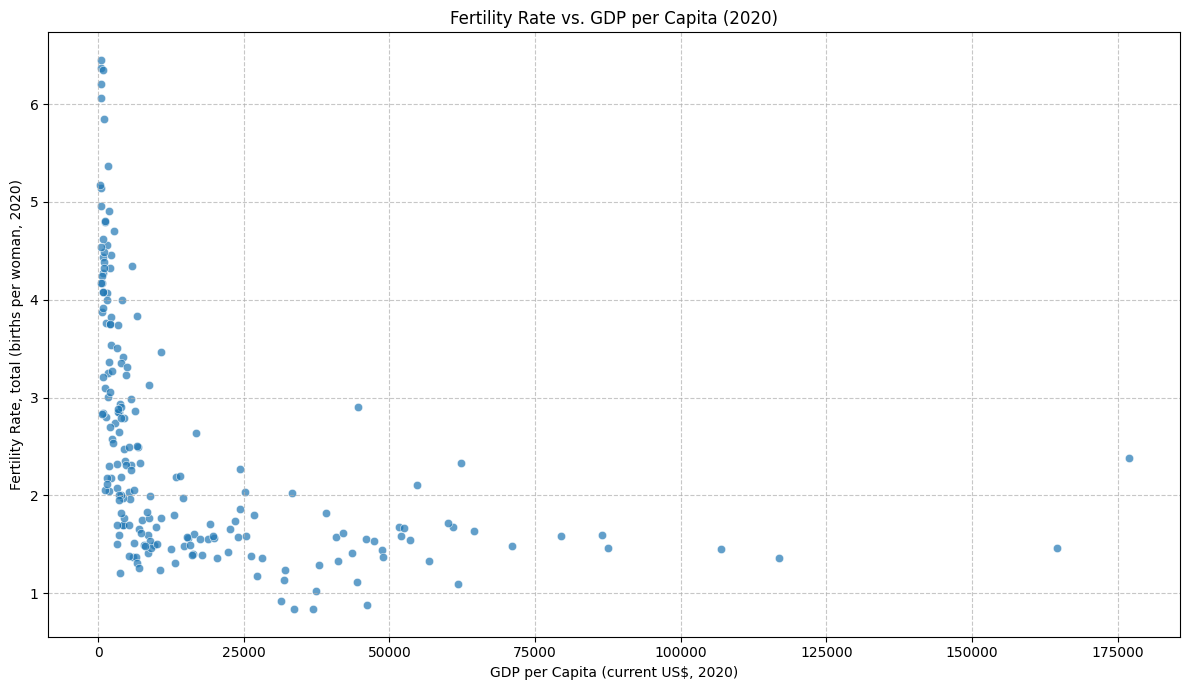

In [74]:
# Construct a scatter plot for 2020 data
plt.figure(figsize=(12, 7))
sns.scatterplot(data=merged_q4_df, x='GDP_per_capita_2020', y='FertilityRate_2020', alpha=0.7)
plt.title('Fertility Rate vs. GDP per Capita (2020)')
plt.xlabel('GDP per Capita (current US$, 2020)')
plt.ylabel('Fertility Rate, total (births per woman, 2020)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()